In [354]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [355]:
df = pd.read_csv(r"C:\Coding\AIML\ML Projects\Product-Segementation\Dataset\flipkart_com-ecommerce_sample.csv")

In [356]:
df.head()

uniq_id            crawl_timestamp  \
0  c2d766ca982eca8304150849735ffef9  2016-03-25 22:59:23 +0000   
1  7f7036a6d550aaa89d34c77bd39a5e48  2016-03-25 22:59:23 +0000   
2  f449ec65dcbc041b6ae5e6a32717d01b  2016-03-25 22:59:23 +0000   
3  0973b37acd0c664e3de26e97e5571454  2016-03-25 22:59:23 +0000   
4  bc940ea42ee6bef5ac7cea3fb5cfbee7  2016-03-25 22:59:23 +0000   

                                                                                             product_url  \
0    http://www.flipkart.com/alisha-solid-women-s-cycling-shorts/p/itmeh2ffvzetthbb?pid=SRTEH2FF9KEDEFGF   
1    http://www.flipkart.com/fabhomedecor-fabric-double-sofa-bed/p/itmeh3qgfamccfpy?pid=SBEEH3QGU7MFYJFY   
2                             http://www.flipkart.com/aw-bellies/p/itmeh4grgfbkexnt?pid=SHOEH4GRSUBJGZXE   
3    http://www.flipkart.com/alisha-solid-women-s-cycling-shorts/p/itmeh2f6sdgah2pq?pid=SRTEH2F6HUZMQ6SJ   
4  http://www.flipkart.com/sicons-all-purpose-arnica-dog-shampoo/p/itmeh3zyw2vhgsp5?pid=PSOEH3ZYDMSYARJ5   

                            product_name  \
0    Alisha Solid Women's Cycling Shorts   
1    FabHomeDecor Fabric Double Sofa Bed   
2                             AW Bellies   
3    Alisha Solid Women's Cycling Shorts   
4  Sicons All Purpose Arnica Dog Shampoo   

                                                                                                              product_category_tree  \
0  ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]   
1               ["Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo..."]   
2                                                                      ["Footwear >> Women's Footwear >> Ballerinas >> AW Bellies"]   
3  ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]   
4                     ["Pet Supplies >> Grooming >> Skin & Coat Care >> Shampoo >> Sicons All Purpose Arnica Dog Shampoo (500 ml)"]   

                pid  retail_price  discounted_price  \
0  SRTEH2FF9KEDEFGF         999.0             379.0   
1  SBEEH3QGU7MFYJFY       32157.0           22646.0   
2  SHOEH4GRSUBJGZXE         999.0             499.0   
3  SRTEH2F6HUZMQ6SJ         699.0             267.0   
4  PSOEH3ZYDMSYARJ5         220.0             210.0   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         image  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                ["http://img5a.flixcart.com/image/short/u/4/a/altht-3p-21-alisha-38-original-imaeh2d5vm5zbtgg.jpeg", "http://img5a.flixcart.com/image/short/p/j/z/altght4p-26-alisha-38-original-imaeh2d5kbufss6n.jpeg", "http://img5a.flixcart.com/image/short/p/j/

In [357]:
df.shape

(20000, 15)

In [358]:
df.columns

Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications'],
      dtype='object')

In [359]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  20000 non-null  object 
 1   crawl_timestamp          20000 non-null  object 
 2   product_url              20000 non-null  object 
 3   product_name             20000 non-null  object 
 4   product_category_tree    20000 non-null  object 
 5   pid                      20000 non-null  object 
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19997 non-null  object 
 9   is_FK_Advantage_product  20000 non-null  bool   
 10  description              19998 non-null  object 
 11  product_rating           20000 non-null  object 
 12  overall_rating           20000 non-null  object 
 13  brand                    14136 non-null  object 
 14  product_specifications

In [360]:
df.isnull().sum()

uniq_id                       0
crawl_timestamp               0
product_url                   0
product_name                  0
product_category_tree         0
pid                           0
retail_price                 78
discounted_price             78
image                         3
is_FK_Advantage_product       0
description                   2
product_rating                0
overall_rating                0
brand                      5864
product_specifications       14
dtype: int64

In [361]:
df['product_rating'] = pd.to_numeric(df['product_rating'], errors='coerce')
df['overall_rating'] = pd.to_numeric(df['overall_rating'], errors='coerce')

In [362]:
print(df['product_rating'].isnull().sum())
print(df['overall_rating'].isnull().sum())

18151
18151


In [363]:
# Dropping the rating columns as mostly are just null values
df_cleaned = df.drop(['product_rating','overall_rating'],axis=1)

In [364]:
df_cleaned.head()

uniq_id            crawl_timestamp  \
0  c2d766ca982eca8304150849735ffef9  2016-03-25 22:59:23 +0000   
1  7f7036a6d550aaa89d34c77bd39a5e48  2016-03-25 22:59:23 +0000   
2  f449ec65dcbc041b6ae5e6a32717d01b  2016-03-25 22:59:23 +0000   
3  0973b37acd0c664e3de26e97e5571454  2016-03-25 22:59:23 +0000   
4  bc940ea42ee6bef5ac7cea3fb5cfbee7  2016-03-25 22:59:23 +0000   

                                                                                             product_url  \
0    http://www.flipkart.com/alisha-solid-women-s-cycling-shorts/p/itmeh2ffvzetthbb?pid=SRTEH2FF9KEDEFGF   
1    http://www.flipkart.com/fabhomedecor-fabric-double-sofa-bed/p/itmeh3qgfamccfpy?pid=SBEEH3QGU7MFYJFY   
2                             http://www.flipkart.com/aw-bellies/p/itmeh4grgfbkexnt?pid=SHOEH4GRSUBJGZXE   
3    http://www.flipkart.com/alisha-solid-women-s-cycling-shorts/p/itmeh2f6sdgah2pq?pid=SRTEH2F6HUZMQ6SJ   
4  http://www.flipkart.com/sicons-all-purpose-arnica-dog-shampoo/p/itmeh3zyw2vhgsp5?pid=PSOEH3ZYDMSYARJ5   

                            product_name  \
0    Alisha Solid Women's Cycling Shorts   
1    FabHomeDecor Fabric Double Sofa Bed   
2                             AW Bellies   
3    Alisha Solid Women's Cycling Shorts   
4  Sicons All Purpose Arnica Dog Shampoo   

                                                                                                              product_category_tree  \
0  ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]   
1               ["Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo..."]   
2                                                                      ["Footwear >> Women's Footwear >> Ballerinas >> AW Bellies"]   
3  ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]   
4                     ["Pet Supplies >> Grooming >> Skin & Coat Care >> Shampoo >> Sicons All Purpose Arnica Dog Shampoo (500 ml)"]   

                pid  retail_price  discounted_price  \
0  SRTEH2FF9KEDEFGF         999.0             379.0   
1  SBEEH3QGU7MFYJFY       32157.0           22646.0   
2  SHOEH4GRSUBJGZXE         999.0             499.0   
3  SRTEH2F6HUZMQ6SJ         699.0             267.0   
4  PSOEH3ZYDMSYARJ5         220.0             210.0   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         image  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                ["http://img5a.flixcart.com/image/short/u/4/a/altht-3p-21-alisha-38-original-imaeh2d5vm5zbtgg.jpeg", "http://img5a.flixcart.com/image/short/p/j/z/altght4p-26-alisha-38-original-imaeh2d5kbufss6n.jpeg", "http://img5a.flixcart.com/image/short/p/j/

In [365]:
df[['retail_price', 'discounted_price']].describe()

,retail_price,discounted_price
count,19922.000000,19922.000000
mean,2979.206104,1973.401767
std,9009.639341,7333.586040
min,35.000000,35.000000
25%,666.000000,350.000000
50%,1040.000000,550.000000
75%,1999.000000,999.000000
max,571230.000000,571230.000000


In [366]:
df_cleaned = df_cleaned[df_cleaned['retail_price']<50000]
df_cleaned = df_cleaned[df_cleaned['discounted_price']<50000]

In [367]:
df_cleaned

uniq_id            crawl_timestamp  \
0      c2d766ca982eca8304150849735ffef9  2016-03-25 22:59:23 +0000   
1      7f7036a6d550aaa89d34c77bd39a5e48  2016-03-25 22:59:23 +0000   
2      f449ec65dcbc041b6ae5e6a32717d01b  2016-03-25 22:59:23 +0000   
3      0973b37acd0c664e3de26e97e5571454  2016-03-25 22:59:23 +0000   
4      bc940ea42ee6bef5ac7cea3fb5cfbee7  2016-03-25 22:59:23 +0000   
...                                 ...                        ...   
19995  7179d2f6c4ad50a17d014ca1d2815156  2015-12-01 10:15:43 +0000   
19996  71ac419198359d37b8fe5e3fffdfee09  2015-12-01 10:15:43 +0000   
19997  93e9d343837400ce0d7980874ece471c  2015-12-01 10:15:43 +0000   
19998  669e79b8fa5d9ae020841c0c97d5e935  2015-12-01 10:15:43 +0000   
19999  cb4fa87a874f715fff567f7b7b3be79c  2015-12-01 10:15:43 +0000   

                                                                                                   product_url  \
0          http://www.flipkart.com/alisha-solid-women-s-cycling-shorts/p/itmeh2ffvzetthbb?pid=SRTEH2FF9KEDEFGF   
1          http://www.flipkart.com/fabhomedecor-fabric-double-sofa-bed/p/itmeh3qgfamccfpy?pid=SBEEH3QGU7MFYJFY   
2                                   http://www.flipkart.com/aw-bellies/p/itmeh4grgfbkexnt?pid=SHOEH4GRSUBJGZXE   
3          http://www.flipkart.com/alisha-solid-women-s-cycling-shorts/p/itmeh2f6sdgah2pq?pid=SRTEH2F6HUZMQ6SJ   
4        http://www.flipkart.com/sicons-all-purpose-arnica-dog-shampoo/p/itmeh3zyw2vhgsp5?pid=PSOEH3ZYDMSYARJ5   
...                                                                                                        ...   
19995           http://www.flipkart.com/walldesign-small-vinyl-sticker/p/itme7kfjrkg85v9k?pid=STIE7KFJAKSTDY9G   
19996  http://www.flipkart.com/wallmantra-large-vinyl-stickers-sticker/p/itme9f5uyrchcxhf?pid=STIE9F5URNQGJCGH   
19997  http://www.flipkart.com/elite-collection-medium-acrylic-sticker/p/itme7vayjzekyybt?pid=STIE7VAYDKQZEBSD   
19998  http://www.flipkart.com/elite-collection-medium-acrylic-sticker/p/itme8ysvxzhqadmw?pid=STIE8YSVEPPCZ42Y   
19999  http://www.flipkart.com/elite-collection-medium-acrylic-sticker/p/itme88knfk6p45ea?pid=STIE88KN9ZDSGZKY   

                                  product_name  \
0          Alisha Solid Women's Cycling Shorts   
1          FabHomeDecor Fabric Double Sofa Bed   
2                                   AW Bellies   
3          Alisha Solid Women's Cycling Shorts   
4        Sicons All Purpose Arnica Dog Shampoo   
...                                        ...   
19995           WallDesign Small Vinyl Sticker   
19996  Wallmantra Large Vinyl Stickers Sticker   
19997  Elite Collection Medium Acrylic Sticker   
19998  Elite Collection Medium Acrylic Sticker   
19999  Elite Collection Medium Acrylic Sticker   

                                                                                                                  product_category_tree  \
0      ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]   
1                   ["Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo..."]   
2                                                                          ["Footwear >> Women's Footwear >> Ballerinas >> AW Bellies"]   
3      ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]   
4                         ["Pet Supplies >> Grooming >> Skin & Coat Care >> Shampoo >> Sicons All Purpose Arnica Dog Shampoo (500 ml)"]   
...                                                                                                                                 ...   
19995                                                             ["Baby Care >> Baby & Kids Gifts >> Stickers >> WallDesign Stickers"]   
19996                                                             ["Baby Care >> Baby & Kids Gifts >> Sticker

Removing useless columns that wont be meeded in clustering

In [368]:
df_cleaned['brand'].isnull().sum()

np.int64(5847)

In [369]:
df_cleaned = df_cleaned[['product_name','product_category_tree', 'retail_price', 'discounted_price', 'is_FK_Advantage_product', 'brand']]

In [370]:
df_cleaned.head()

,product_name,product_category_tree,retail_price,discounted_price,is_FK_Advantage_product,brand
0,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",999.0,379.0,False,Alisha
1,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo...""]",32157.0,22646.0,False,FabHomeDecor
2,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >> AW Bellies""]",999.0,499.0,False,AW
3,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",699.0,267.0,False,Alisha
4,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care >> Shampoo >> Sicons All Purpose Arnica Dog Shampoo (500 ml)""]",220.0,210.0,False,Sicons


In [371]:
df_cleaned.isnull().sum()
# Null in Brand means local or unregistered brand

product_name                  0
product_category_tree         0
retail_price                  0
discounted_price              0
is_FK_Advantage_product       0
brand                      5847
dtype: int64

array([[<Axes: title={'center': 'retail_price'}>,
        <Axes: title={'center': 'discounted_price'}>]], dtype=object)

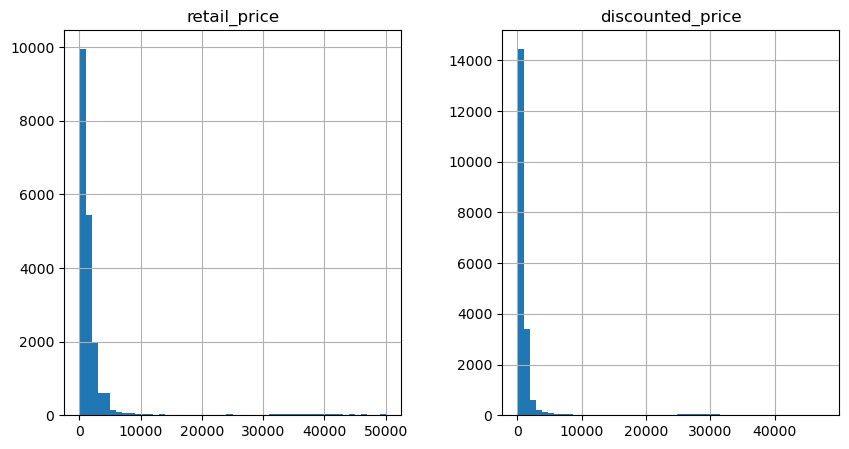

In [372]:
df_cleaned[['retail_price', 'discounted_price']].hist(bins=50, figsize=(10,5))

In [373]:
pd.set_option('display.max_colwidth', None)
df_cleaned['product_category_tree'].head()

0    ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]
1                 ["Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo..."]
2                                                                        ["Footwear >> Women's Footwear >> Ballerinas >> AW Bellies"]
3    ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]
4                       ["Pet Supplies >> Grooming >> Skin & Coat Care >> Shampoo >> Sicons All Purpose Arnica Dog Shampoo (500 ml)"]
Name: product_category_tree, dtype: object

In [374]:
df_cleaned["Main_Category"] = df_cleaned['product_category_tree'].str.split(">>").str[0]

In [375]:
df_cleaned

,product_name,product_category_tree,retail_price,discounted_price,is_FK_Advantage_product,brand,Main_Category
0,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",999.0,379.0,False,Alisha,"[""Clothing"
1,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo...""]",32157.0,22646.0,False,FabHomeDecor,"[""Furniture"
2,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >> AW Bellies""]",999.0,499.0,False,AW,"[""Footwear"
3,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",699.0,267.0,False,Alisha,"[""Clothing"
4,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care >> Shampoo >> Sicons All Purpose Arnica Dog Shampoo (500 ml)""]",220.0,210.0,False,Sicons,"[""Pet Supplies"
...,...,...,...,...,...,...,...
19995,WallDesign Small Vinyl Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> WallDesign Stickers""]",1500.0,730.0,False,WallDesign,"[""Baby Care"
19996,Wallmantra Large Vinyl Stickers Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Wallmantra Stickers""]",1429.0,1143.0,False,Wallmantra,"[""Baby Care"
19997,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Elite Collection Stickers""]",1299.0,999.0,False,Elite Collection,"[""Baby Care"
19998,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Elite Collection Stickers""]",1499.0,1199.0,False,Elite Collection,"[""Baby Care"


In [376]:
df_cleaned['Main_Category'] = df_cleaned['Main_Category'].str.replace('[\\[\\]\"]', '', regex=True)

In [377]:
df_cleaned

,product_name,product_category_tree,retail_price,discounted_price,is_FK_Advantage_product,brand,Main_Category
0,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",999.0,379.0,False,Alisha,Clothing
1,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo...""]",32157.0,22646.0,False,FabHomeDecor,Furniture
2,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >> AW Bellies""]",999.0,499.0,False,AW,Footwear
3,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",699.0,267.0,False,Alisha,Clothing
4,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care >> Shampoo >> Sicons All Purpose Arnica Dog Shampoo (500 ml)""]",220.0,210.0,False,Sicons,Pet Supplies
...,...,...,...,...,...,...,...
19995,WallDesign Small Vinyl Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> WallDesign Stickers""]",1500.0,730.0,False,WallDesign,Baby Care
19996,Wallmantra Large Vinyl Stickers Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Wallmantra Stickers""]",1429.0,1143.0,False,Wallmantra,Baby Care
19997,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Elite Collection Stickers""]",1299.0,999.0,False,Elite Collection,Baby Care
19998,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Elite Collection Stickers""]",1499.0,1199.0,False,Elite Collection,Baby Care


In [378]:
df_cleaned['Main_Category'].nunique()

263

In [379]:
df_cleaned['Main_Category'].value_counts().head(10)

Main_Category
Clothing                       6170
Jewellery                      3522
Footwear                       1225
Mobiles & Accessories          1096
Automotive                     1010
Home Decor & Festive Needs      927
Beauty and Personal Care        709
Home Furnishing                 700
Kitchen & Dining                645
Computers                       573
Name: count, dtype: int64

In [380]:
df_cleaned['discount_percent'] = ((df_cleaned['retail_price'] - df_cleaned['discounted_price']) / df_cleaned['retail_price']) * 100

In [381]:
df_cleaned

,product_name,product_category_tree,retail_price,discounted_price,is_FK_Advantage_product,brand,Main_Category,discount_percent
0,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",999.0,379.0,False,Alisha,Clothing,62.062062
1,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo...""]",32157.0,22646.0,False,FabHomeDecor,Furniture,29.576764
2,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >> AW Bellies""]",999.0,499.0,False,AW,Footwear,50.050050
3,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",699.0,267.0,False,Alisha,Clothing,61.802575
4,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care >> Shampoo >> Sicons All Purpose Arnica Dog Shampoo (500 ml)""]",220.0,210.0,False,Sicons,Pet Supplies,4.545455
...,...,...,...,...,...,...,...,...
19995,WallDesign Small Vinyl Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> WallDesign Stickers""]",1500.0,730.0,False,WallDesign,Baby Care,51.333333
19996,Wallmantra Large Vinyl Stickers Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Wallmantra Stickers""]",1429.0,1143.0,False,Wallmantra,Baby Care,20.013996
19997,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Elite Collection Stickers""]",1299.0,999.0,False,Elite Collection,Baby Care,23.094688
19998,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Elite Collection Stickers""]",1499.0,1199.0,False,Elite Collection,Baby Care,20.013342


In [382]:
df_cleaned.describe()

,retail_price,discounted_price,discount_percent
count,19892.000000,19892.000000,19892.000000
mean,2809.373919,1837.698572,40.551571
std,6868.174191,5227.112919,23.544474
min,35.000000,35.000000,0.000000
25%,666.000000,350.000000,21.108179
50%,1025.000000,550.000000,45.022511
75%,1999.000000,999.000000,59.976784
max,49999.000000,47620.000000,96.533333


<Axes: xlabel='discounted_price', ylabel='Count'>

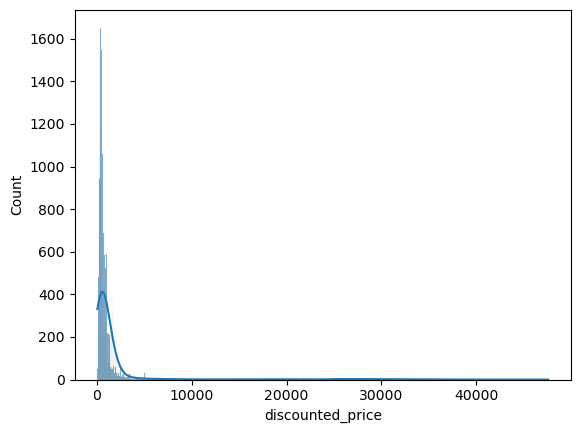

In [383]:
sns.histplot(data=df_cleaned,x='discounted_price',kde=True)

In [384]:
df_cleaned['price_log'] = np.log1p(df_cleaned['discounted_price'])

In [385]:
df_cleaned

,product_name,product_category_tree,retail_price,discounted_price,is_FK_Advantage_product,brand,Main_Category,discount_percent,price_log
0,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",999.0,379.0,False,Alisha,Clothing,62.062062,5.940171
1,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo...""]",32157.0,22646.0,False,FabHomeDecor,Furniture,29.576764,10.027783
2,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >> AW Bellies""]",999.0,499.0,False,AW,Footwear,50.050050,6.214608
3,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts""]",699.0,267.0,False,Alisha,Clothing,61.802575,5.590987
4,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care >> Shampoo >> Sicons All Purpose Arnica Dog Shampoo (500 ml)""]",220.0,210.0,False,Sicons,Pet Supplies,4.545455,5.351858
...,...,...,...,...,...,...,...,...,...
19995,WallDesign Small Vinyl Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> WallDesign Stickers""]",1500.0,730.0,False,WallDesign,Baby Care,51.333333,6.594413
19996,Wallmantra Large Vinyl Stickers Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Wallmantra Stickers""]",1429.0,1143.0,False,Wallmantra,Baby Care,20.013996,7.042286
19997,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Elite Collection Stickers""]",1299.0,999.0,False,Elite Collection,Baby Care,23.094688,6.907755
19998,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >> Elite Collection Stickers""]",1499.0,1199.0,False,Elite Collection,Baby Care,20.013342,7.090077


In [386]:
df_cleaned['is_branded'] = df['brand'].notnull().astype(int)

In [387]:
df_cleaned['is_branded'].value_counts()

is_branded
1    14045
0     5847
Name: count, dtype: int64

In [388]:
df_final = df_cleaned[['discount_percent','price_log']]

In [389]:
df_final

,discount_percent,price_log
0,62.062062,5.940171
1,29.576764,10.027783
2,50.050050,6.214608
3,61.802575,5.590987
4,4.545455,5.351858
...,...,...
19995,51.333333,6.594413
19996,20.013996,7.042286
19997,23.094688,6.907755
19998,20.013342,7.090077


In [390]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_final)

In [391]:
df_scaled

array([[ 0.91363402, -0.55752371],
       [-0.46614261,  3.30718543],
       [ 0.40343727, -0.29805223],
       ...,
       [-0.74146151,  0.35729682],
       [-0.87233823,  0.52967616],
       [-0.30564204,  0.35729682]])

In [392]:
from sklearn.cluster import KMeans, DBSCAN

In [393]:
inertia= []
K_range = range(1,11)

In [394]:
for k in K_range:
    k_means = KMeans(n_clusters=k,random_state=42)
    k_means.fit(df_scaled)
    inertia.append(k_means.inertia_)

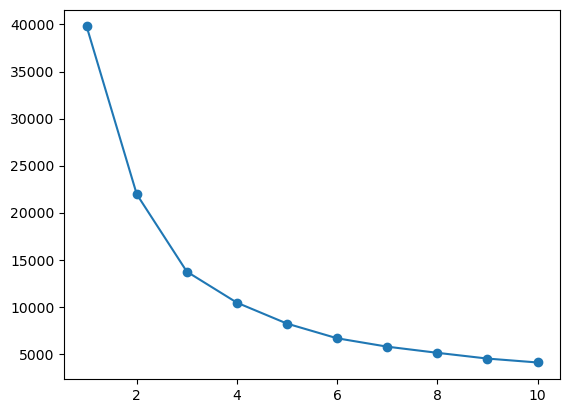

In [395]:
plt.plot(K_range,inertia,marker='o')

In [396]:
k_means_final = KMeans(n_clusters=3,random_state=42)
clusters = k_means_final.fit_predict(df_scaled)
df_final['Cluster'] = clusters

In [397]:
df_final

,discount_percent,price_log,Cluster
0,62.062062,5.940171,1
1,29.576764,10.027783,2
2,50.050050,6.214608,1
3,61.802575,5.590987,1
4,4.545455,5.351858,0
...,...,...,...
19995,51.333333,6.594413,1
19996,20.013996,7.042286,0
19997,23.094688,6.907755,0
19998,20.013342,7.090077,0


<Axes: xlabel='discount_percent', ylabel='price_log'>

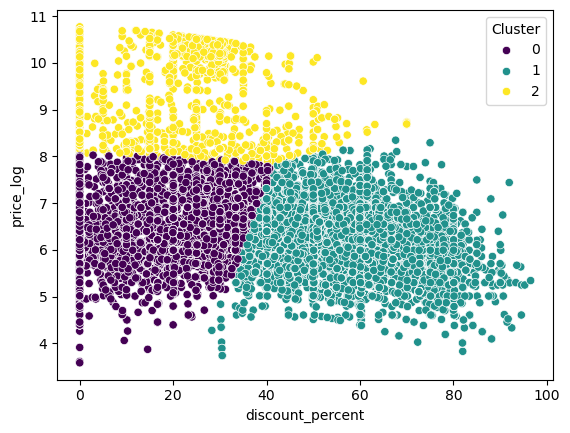

In [398]:
sns.scatterplot(data=df_final,x='discount_percent',y='price_log',hue='Cluster',palette='viridis')

In [399]:
cluster_summary = df_final.groupby('Cluster').mean()
print(cluster_summary)

         discount_percent  price_log
Cluster                             
0               15.087538   6.530921
1               57.130637   6.193265
2               21.994023   9.431447


In [400]:
cluster_names = {
    0: "Regular Products",
    1: "High Discount Products",
    2: "Premium Products"
}

df_final['cluster_name'] = df_final['Cluster'].map(cluster_names)

In [402]:
df_final['Cluster'].value_counts()

Cluster
1    11823
0     6700
2     1369
Name: count, dtype: int64

In [403]:
df_final

,discount_percent,price_log,Cluster,cluster_name
0,62.062062,5.940171,1,High Discount Products
1,29.576764,10.027783,2,Premium Products
2,50.050050,6.214608,1,High Discount Products
3,61.802575,5.590987,1,High Discount Products
4,4.545455,5.351858,0,Regular Products
...,...,...,...,...
19995,51.333333,6.594413,1,High Discount Products
19996,20.013996,7.042286,0,Regular Products
19997,23.094688,6.907755,0,Regular Products
19998,20.013342,7.090077,0,Regular Products


,discount_percent,price_log,Cluster,cluster_name
0,62.062062,5.940171,1,High Discount Products
1,29.576764,10.027783,2,Premium Products
2,50.050050,6.214608,1,High Discount Products
3,61.802575,5.590987,1,High Discount Products
4,4.545455,5.351858,0,Regular Products
...,...,...,...,...
19995,51.333333,6.594413,1,High Discount Products
19996,20.013996,7.042286,0,Regular Products
19997,23.094688,6.907755,0,Regular Products
19998,20.013342,7.090077,0,Regular Products
